# <center> Predicción de Precios en Bienes Raíces - Mercado Australiano - Regresión Avanzada con PyCaret

# Tabla de Contenido

1. [Introducción](#Introducción)
2. [Configuración e Instalación](#Configuración-e-Instalación)
3. [Entendimiento de los Datos](#Entendimiento-de-los-Datos)  
4. [Manipulación y Limpieza de Datos](#Manipulación-y-Limpieza-de-Datos)
    1. [Dropping Data](#Dropping-Data)
    2. [Derived Data](#Derived-Data)
5. [Análisis de Datos](#Análisis-de-Datos)
    1. [Análisis-Univariable](#Análisis-Univariable)
        1. [Plot Numeric Data](#Plot-Numeric-Data)
        2. [Plot Categorical Data](#Plot-Categorical-Data)
    2. [Análisis-Bivariable](#Análisis-Bivariable)
6. [Preparación de Datos y Modelado](#Preparación-de-Datos-y-Modelado)
    1. [Splitting data into Train Test](#Splitting-data-into-Train-Test)
7. [Construcción-del-Modelo](#Model-Building)
    1. [Ridge Regression](#Ridge-Regression)
    2. [Lasso Regression](#Lasso-Regression)
    3. [ElasticNet Regression](#ElasticNet-Regression)
8. [Conclusiones y Observaciones](#Conclusiones-y-Observaciones)

# Introducción

### Integrantes del Grupo:
* De los Rios Aliaga, Mijaelha
* Flores Velasquez, Maritza Karen
* Machaca Lamas, Sergio Alejandro
* Mamani Poma, Alexander Manuel
* Vilela, Bruno



## Entendimiento del Negocio

Una empresa de vivienda con sede en EE. UU. llamada Surprise Housing ha decidido ingresar al mercado australiano. La empresa utiliza el análisis de datos para comprar casas a un precio inferior a sus valores reales y venderlas a un precio más alto. Con el mismo propósito, la empresa ha recopilado un conjunto de datos de la venta de casas en Australia. Los datos se proporcionan en el archivo CSV a continuación.

La compañía está buscando posibles propiedades para comprar e ingresar al mercado. Debe construir un modelo de regresión utilizando la regularización para predecir el valor real de las posibles propiedades y decidir si invertir en ellas o no.

La empresa quiere saber:

* Qué variables son significativas para predecir el precio de una casa, y
* Qué tan bien esas variables describen el precio de una casa.

Además, determine el valor óptimo de lambda para la regresión de Ridge y Lasso.

### Objetivo del Negocio:

Debe modelar el precio de las casas con las variables independientes disponibles. Luego, la gerencia utilizará este modelo para comprender cómo varían exactamente los precios con las variables. En consecuencia, pueden manipular la estrategia de la empresa y concentrarse en áreas que generarán altos rendimientos. Además, el modelo será una buena manera para que la gerencia entienda la dinámica de precios de un nuevo mercado.

# Configuración e Instalación

In [1]:
# Instalar PyCaret 4.0 (compatible con Python 3.12 de Colab)
!pip install git+https://github.com/pycaret/pycaret.git@v4.0.0a0 -q

In [2]:
# Importar Librerías Requeridas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab
import seaborn as sns
import sys
import pycaret

# Importar Librerías de Machine Learning
import sklearn
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# Importar Librerías de Estadística
import statsmodels.api as stats
from statsmodels.api import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# Ignorar Alertas (Warnings)
import warnings
warnings.filterwarnings('ignore')

# Definir precisión del FLOAT a dos dígitos.
pd.options.display.float_format = '{:.2f}'.format

In [3]:
# Leer el DATASET CSV con en un Dataframe.
# Funciona en local (ruta relativa desde la raiz del repositorio) y en Google Colab (solicita la subida del archivo)
import os

# Dirección relativa del Dataset
DATA_FILE_PATH = '_data/dataset.csv'

EN_COLAB = 'google.colab' in sys.modules

if not os.path.exists(DATA_FILE_PATH):
    if EN_COLAB:
        from google.colab import files
        os.makedirs('_data', exist_ok=True)
        print('Sube el archivo dataset.csv:')
        subidos = files.upload()
        os.rename(list(subidos.keys())[0], DATA_FILE_PATH)
    else:
        raise FileNotFoundError(
            f'No se encontro {DATA_FILE_PATH}. Ejecuta el notebook desde la raiz del repositorio.')

raw_data = pd.read_csv(DATA_FILE_PATH)
print(raw_data.shape)

(1460, 81)


# Entendimiento de los Datos
### Dimensiones y Estructura del Dataset

In [4]:
# Ver dimensiones del dataset (filas, columnas)
print(raw_data.shape)
raw_data.info()

(1460, 81)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Primeras Filas del Dataset

In [5]:
# Ver las primeras filas del dataset
raw_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Estadísticas Descriptivas

In [6]:
# Estadisticas descriptivas de variables numericas
raw_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.00,1460.00,1201.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1460.00,...,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,730.50,56.90,70.05,10516.83,6.10,5.58,1971.27,1984.87,103.69,443.64,...,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,2007.82,180921.20
std,421.61,42.30,24.28,9981.26,1.38,1.11,30.20,20.65,181.07,456.10,...,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33,79442.50
min,1.00,20.00,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,34900.00
25%,365.75,20.00,59.00,7553.50,5.00,5.00,1954.00,1967.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00,129975.00
50%,730.50,50.00,69.00,9478.50,6.00,5.00,1973.00,1994.00,0.00,383.50,...,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,163000.00
75%,1095.25,70.00,80.00,11601.50,7.00,6.00,2000.00,2004.00,166.00,712.25,...,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,214000.00
max,1460.00,190.00,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,...,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00,755000.00


### Variable Objetivo: SalePrice

In [7]:
# Estadisticas de la variable objetivo
raw_data['SalePrice'].describe()

count     1460.00
mean    180921.20
std      79442.50
min      34900.00
25%     129975.00
50%     163000.00
75%     214000.00
max     755000.00
Name: SalePrice, dtype: float64

### Valores Faltantes

In [8]:
# Ver cantidad de valores faltantes por columna
missing = raw_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


## Manipulación y Limpieza de Datos

### Dropping Data

In [9]:
# Eliminar columna Id, no aporta informacion para el modelo
df = raw_data.drop(columns=['Id'])

In [10]:
# Eliminar columnas con demasiados valores faltantes (mas del 80%)
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
df = df.drop(columns=cols_to_drop)
print(df.shape)

(1460, 76)


In [11]:
# Verificar duplicados
print(df.duplicated().sum())

0


### Derived Data

In [12]:
# Rellenar valores NA que representan "sin caracteristica" segun el diccionario de datos
cols_none = ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
df[cols_none] = df[cols_none].fillna('None')

In [13]:
# Rellenar valores numericos faltantes con la mediana o cero segun corresponda
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

In [14]:
# Eliminar las pocas filas restantes con valores faltantes (Electrical)
df = df.dropna()
print(df.shape)
print(df.isnull().sum().sum())

(1459, 76)
0


# Análisis de Datos

Con el dataset ya limpio (1459 filas x 76 columnas) se explora el comportamiento de las variables antes de modelar. El objetivo es identificar la forma de la distribución de la variable objetivo, detectar valores atípicos y multicolinealidad, y reconocer qué variables se relacionan con el precio de venta.

In [15]:
# Separar las variables numericas y categoricas para el analisis
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables numericas  : {len(num_cols)}')
print(f'Variables categoricas: {len(cat_cols)}')

Variables numericas  : 37
Variables categoricas: 39


## Análisis Univariable

### Plot Numeric Data

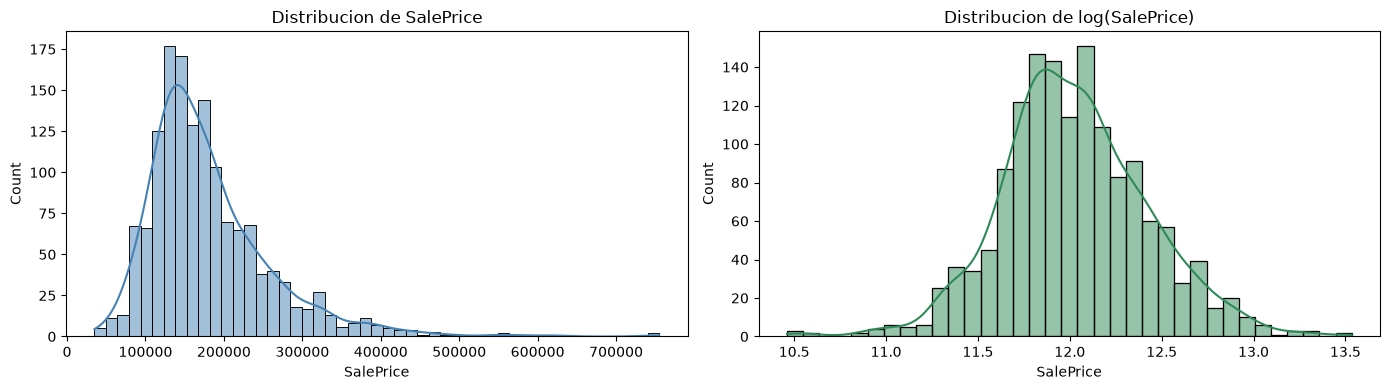

Asimetria (skew) original : 1.8819
Curtosis original         : 6.5293
Asimetria con log1p       : 0.1213


In [16]:
# Distribucion de la variable objetivo, en escala original y logaritmica
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribucion de SalePrice')
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribucion de log(SalePrice)')
plt.tight_layout()
plt.show()

print(f"Asimetria (skew) original : {df['SalePrice'].skew():.4f}")
print(f"Curtosis original         : {df['SalePrice'].kurt():.4f}")
print(f"Asimetria con log1p       : {np.log1p(df['SalePrice']).skew():.4f}")

La variable `SalePrice` presenta una asimetría positiva marcada (1.88) y colas pesadas: la media (180 930) supera a la mediana (163 000) y el máximo llega a 755 000. Al aplicar una transformación logarítmica la asimetría baja a 0.12, es decir, la distribución se vuelve prácticamente simétrica. Esto es relevante porque la regresión lineal asume residuos normales.

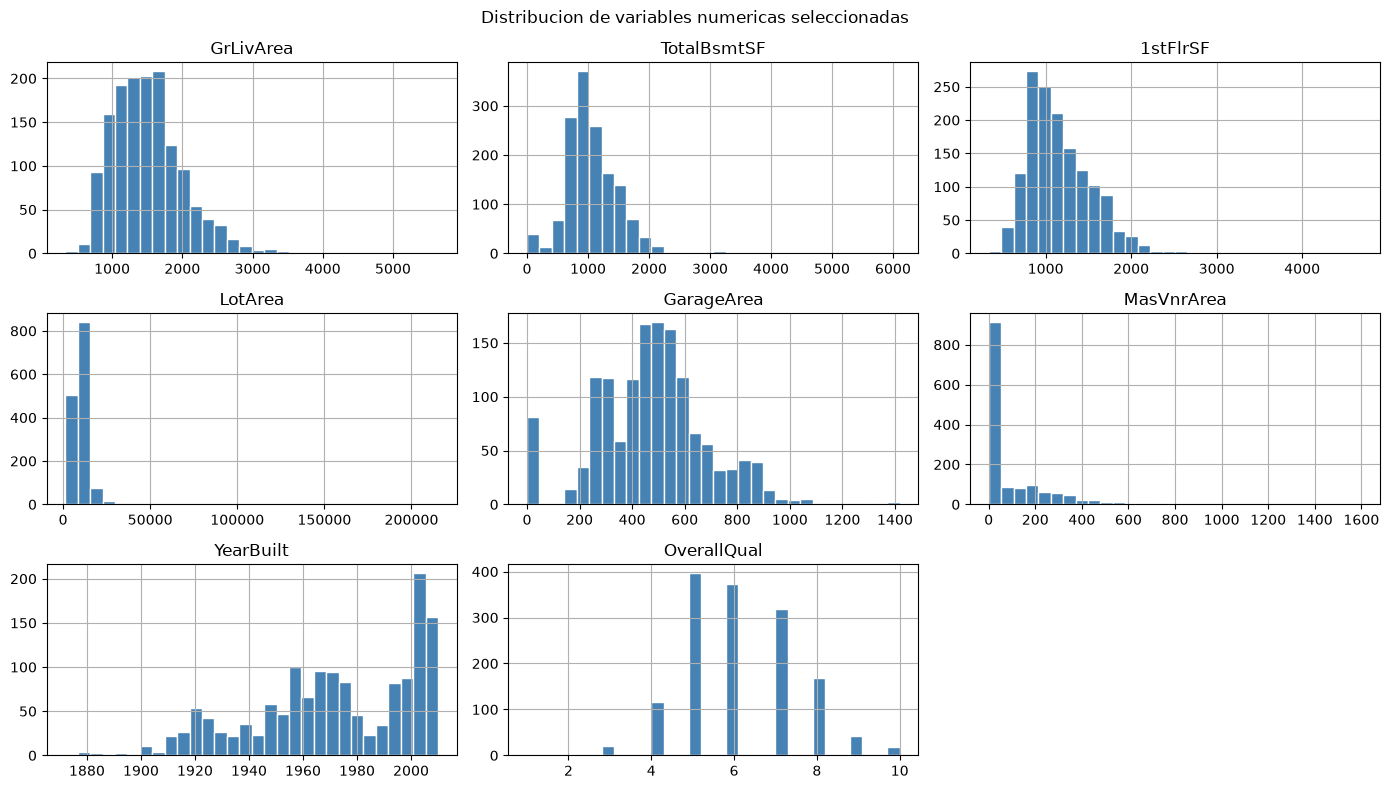

In [17]:
# Distribucion de las principales variables numericas continuas
vars_num = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'LotArea',
            'GarageArea', 'MasVnrArea', 'YearBuilt', 'OverallQual']
df[vars_num].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribucion de variables numericas seleccionadas')
plt.tight_layout()
plt.show()

In [18]:
# Variables numericas con mayor asimetria (candidatas a transformacion)
asimetria = df[num_cols].drop(columns=['SalePrice']).skew().sort_values(ascending=False)
print(asimetria.head(10))

MiscVal         24.47
PoolArea        14.82
LotArea         12.20
3SsnPorch       10.30
LowQualFinSF     9.01
KitchenAbvGr     4.49
BsmtFinSF2       4.25
ScreenPorch      4.12
BsmtHalfBath     4.10
EnclosedPorch    3.09
dtype: float64


Varias variables numéricas están fuertemente sesgadas porque son en realidad *conteos de una característica que la mayoría de las viviendas no posee*: `MiscVal` (24.47), `PoolArea` (14.82) y `3SsnPorch` (10.30) son casi siempre cero. `LotArea` (12.20) sí es continua, pero con unos pocos terrenos enormes que estiran la cola.

### Plot Categorical Data

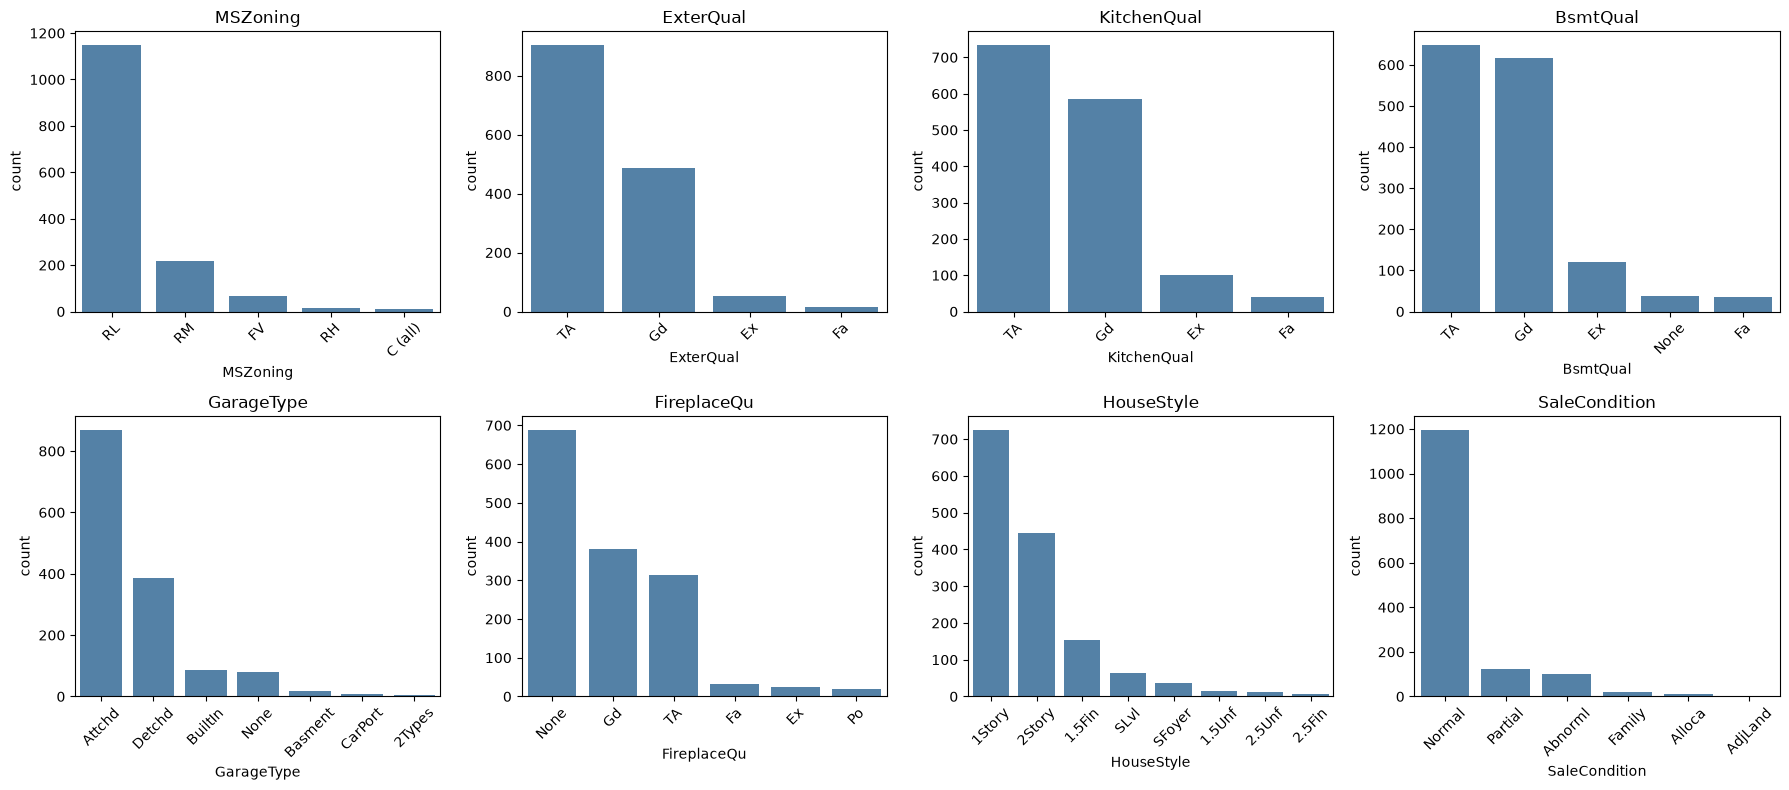

In [19]:
# Frecuencia de las principales variables categoricas
vars_cat = ['MSZoning', 'ExterQual', 'KitchenQual', 'BsmtQual',
            'GarageType', 'FireplaceQu', 'HouseStyle', 'SaleCondition']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), vars_cat):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Variables categoricas dominadas por una sola categoria (aportan poca informacion)
for col in cat_cols:
    prop = df[col].value_counts(normalize=True).iloc[0]
    if prop > 0.95:
        print(f'{col:15} -> {df[col].value_counts().index[0]:10} {prop * 100:.1f}%')

Street          -> Pave       99.6%
Utilities       -> AllPub     99.9%
Condition2      -> Norm       99.0%
RoofMatl        -> CompShg    98.2%
Heating         -> GasA       97.8%


Cinco variables categóricas son prácticamente constantes: `Utilities` (99.9% `AllPub`), `Street` (99.6% `Pave`), `Condition2` (99.0% `Norm`), `RoofMatl` (98.2% `CompShg`) y `Heating` (97.8% `GasA`). Al no presentar variabilidad, no pueden explicar diferencias de precio y son candidatas a eliminarse antes del modelado.

## Análisis Bivariable

In [21]:
# Correlacion de las variables numericas con SalePrice
corr_target = df[num_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
print('Top 10 correlaciones positivas:')
print(corr_target.head(10))
print('\nTop 5 correlaciones negativas:')
print(corr_target.tail(5))

Top 10 correlaciones positivas:
OverallQual    0.79
GrLivArea      0.71
GarageCars     0.64
GarageArea     0.62
TotalBsmtSF    0.61
1stFlrSF       0.61
FullBath       0.56
TotRmsAbvGrd   0.53
YearBuilt      0.52
YearRemodAdd   0.51
Name: SalePrice, dtype: float64

Top 5 correlaciones negativas:
YrSold          -0.03
OverallCond     -0.08
MSSubClass      -0.08
EnclosedPorch   -0.13
KitchenAbvGr    -0.14
Name: SalePrice, dtype: float64


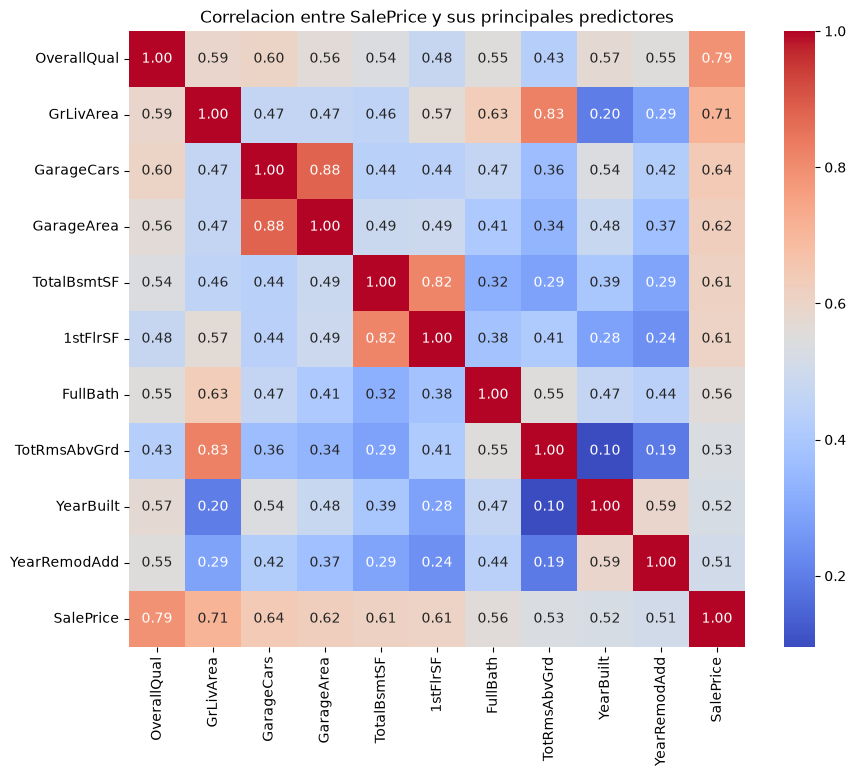

In [22]:
# Mapa de calor de las variables mas correlacionadas con SalePrice
top_corr = corr_target.abs().sort_values(ascending=False).head(10).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlacion entre SalePrice y sus principales predictores')
plt.show()

Las variables numéricas más correlacionadas con el precio son `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62) y `TotalBsmtSF` (0.61): la calidad general y la superficie habitable son los factores dominantes. Las correlaciones negativas son todas débiles, la mayor en valor absoluto es `KitchenAbvGr` (-0.14).

In [23]:
# Pares de variables numericas muy correlacionadas entre si (multicolinealidad)
corr_num = df[num_cols].drop(columns=['SalePrice']).corr().abs()
pares = corr_num.where(np.triu(np.ones(corr_num.shape), k=1).astype(bool)).stack()
print(pares[pares > 0.7].sort_values(ascending=False))

GarageCars   GarageArea     0.88
GrLivArea    TotRmsAbvGrd   0.83
TotalBsmtSF  1stFlrSF       0.82
dtype: float64


Se detectan tres pares con correlación superior a 0.7 que miden esencialmente lo mismo: `GarageCars` ~ `GarageArea` (0.883), `GrLivArea` ~ `TotRmsAbvGrd` (0.826) y `TotalBsmtSF` ~ `1stFlrSF` (0.819). Esta multicolinealidad justifica el uso de regularización y deberá revisarse con el VIF en la etapa de selección de características.

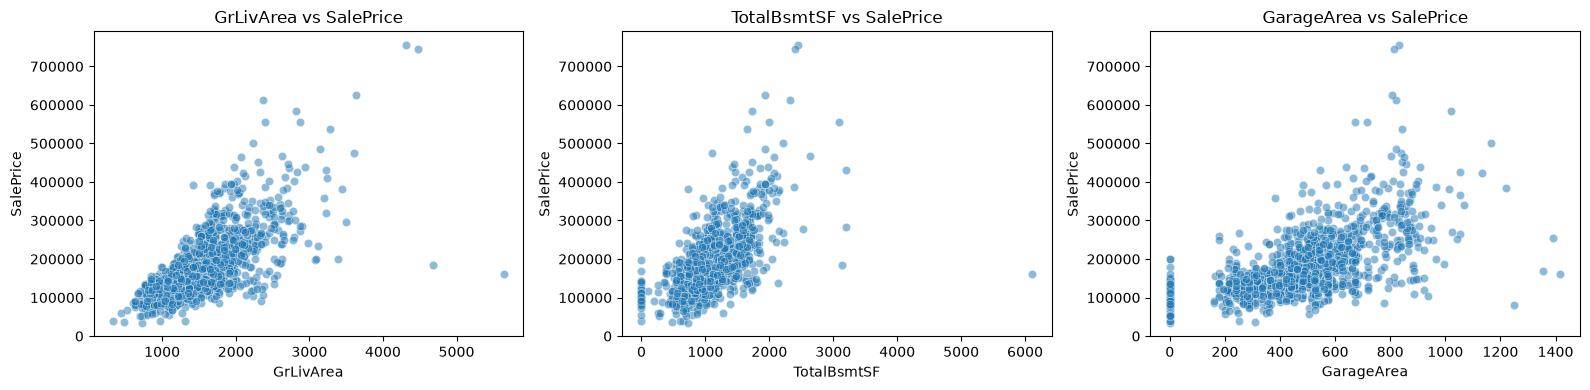

Viviendas con GrLivArea > 4000 y precio < 300000:
      GrLivArea  OverallQual  SalePrice
523        4676           10     184750
1298       5642           10     160000


In [24]:
# Relacion entre las principales variables continuas y SalePrice
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['GrLivArea', 'TotalBsmtSF', 'GarageArea']):
    sns.scatterplot(data=df, x=col, y='SalePrice', ax=ax, alpha=0.5)
    ax.set_title(f'{col} vs SalePrice')
plt.tight_layout()
plt.show()

# Viviendas muy grandes con un precio anormalmente bajo (posibles valores atipicos)
atipicos = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print('Viviendas con GrLivArea > 4000 y precio < 300000:')
print(atipicos[['GrLivArea', 'OverallQual', 'SalePrice']])

La relación entre `GrLivArea` y `SalePrice` es claramente lineal y creciente, salvo por dos observaciones con superficies superiores a 4000 pies cuadrados y calidad máxima (`OverallQual` = 10) vendidas por debajo de 185 000. Son ventas atípicas que conviene tener presentes, ya que pueden afectar de forma desproporcionada a los coeficientes de la regresión.

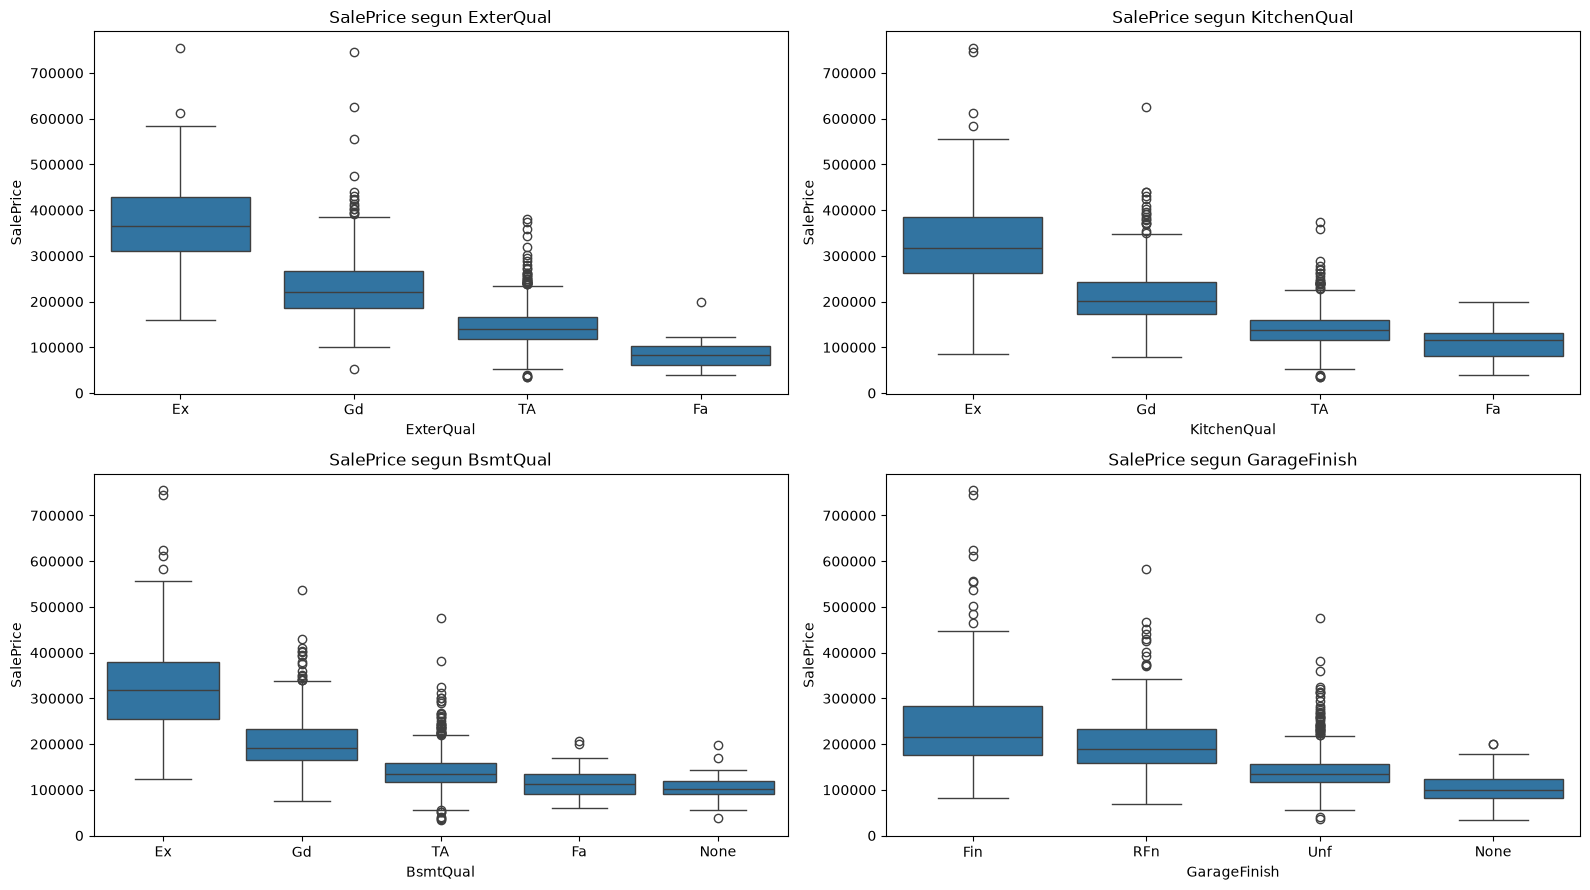

In [25]:
# Distribucion de SalePrice segun las principales variables categoricas
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, col in zip(axes.flatten(), ['ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish']):
    orden = df.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='SalePrice', order=orden, ax=ax)
    ax.set_title(f'SalePrice segun {col}')
plt.tight_layout()
plt.show()

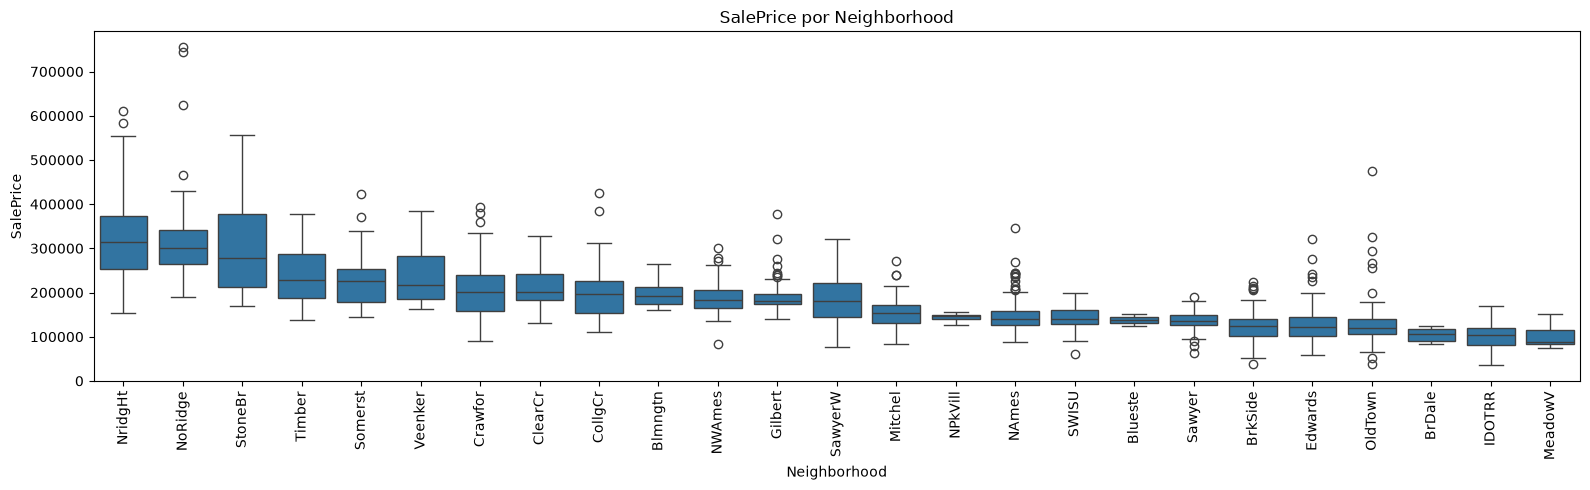

In [26]:
# SalePrice por vecindario, la categorica con mayor poder explicativo
orden = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
plt.figure(figsize=(16, 5))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=orden)
plt.xticks(rotation=90)
plt.title('SalePrice por Neighborhood')
plt.tight_layout()
plt.show()

In [27]:
# Poder explicativo de cada variable categorica sobre SalePrice (eta cuadrado)
media_global = df['SalePrice'].mean()
sst = ((df['SalePrice'] - media_global) ** 2).sum()

eta2 = {}
for col in cat_cols:
    grupos = df.groupby(col)['SalePrice']
    ssb = (grupos.count() * (grupos.mean() - media_global) ** 2).sum()
    eta2[col] = ssb / sst

eta2 = pd.Series(eta2).sort_values(ascending=False)
print(eta2.head(10))

Neighborhood   0.55
ExterQual      0.48
BsmtQual       0.47
KitchenQual    0.46
GarageFinish   0.31
FireplaceQu    0.29
Foundation     0.26
GarageType     0.25
BsmtFinType1   0.21
HeatingQC      0.20
dtype: float64


El estadístico eta cuadrado mide qué proporción de la varianza de `SalePrice` explica cada variable categórica por sí sola. `Neighborhood` encabeza la lista con 0.546, seguida de las variables de calidad `ExterQual` (0.477), `BsmtQual` (0.465) y `KitchenQual` (0.457). La ubicación y la calidad de los acabados son, por tanto, los factores categóricos determinantes del precio.

### Resumen del Análisis

* `SalePrice` tiene asimetría positiva (1.88); la transformación logarítmica la reduce a 0.12 y normaliza la distribución.
* Los predictores numéricos más fuertes son `OverallQual` (r = 0.79) y `GrLivArea` (r = 0.71).
* Los predictores categóricos más fuertes son `Neighborhood` (eta² = 0.546) y las variables de calidad `ExterQual`, `BsmtQual` y `KitchenQual`.
* Existe multicolinealidad relevante en tres pares de variables, lo que respalda el uso de modelos regularizados.
* Cinco variables categóricas son casi constantes y aportan poca información.
* Se identificaron dos ventas atípicas de viviendas grandes a precio bajo.

# Preparación de Datos y Modelado

A partir de los hallazgos del análisis exploratorio, se prepara el dataset para el modelado y se divide en conjuntos de **entrenamiento** y **prueba**. Las decisiones que se aplican antes del split son:

1. **Eliminar variables categóricas casi constantes** (`Utilities`, `Street`, `Condition2`, `RoofMatl`, `Heating`): aportan poca información.
2. **Eliminar las dos ventas atípicas** con `GrLivArea > 4000` y `SalePrice < 300000`: distorsionan los coeficientes de la regresión.
3. **Transformar la variable objetivo** con `log1p(SalePrice)`: reduce la asimetría de 1.88 a ~0.12 y acerca los residuos a normalidad.
4. **Codificar las variables categóricas** restantes con *one-hot encoding* (`pd.get_dummies`), necesario para Ridge / Lasso / ElasticNet.
5. **Separar train/test** (80 % / 20 %) con `random_state` fijo para reproducibilidad.

> **Alcance de esta sección:** deja listos `X_train`, `X_test`, `y_train` y `y_test`. El escalado (`StandardScaler`), la selección de características (RFE / VIF) y el entrenamiento de Ridge, Lasso y ElasticNet corresponden a la **sección 7 — Construcción del Modelo**.

In [28]:
# Aplicar las decisiones del EDA antes de separar train/test
df_model = df.copy()

# 1) Variables categoricas casi constantes (poca informacion)
cols_baja_variabilidad = ['Utilities', 'Street', 'Condition2', 'RoofMatl', 'Heating']
df_model = df_model.drop(columns=cols_baja_variabilidad)

# 2) Dos ventas atipicas: casas muy grandes vendidas a precio anormalmente bajo
n_antes = len(df_model)
df_model = df_model[~((df_model['GrLivArea'] > 4000) & (df_model['SalePrice'] < 300000))]
print(f'Filas eliminadas por atipicos: {n_antes - len(df_model)}')

# 3) Variable objetivo en escala logaritmica
df_model['SalePrice_Log'] = np.log1p(df_model['SalePrice'])

print(f'Dataset listo para modelar: {df_model.shape[0]} filas x {df_model.shape[1]} columnas')
print(f"Asimetria de SalePrice_Log: {df_model['SalePrice_Log'].skew():.4f}")
df_model.head()

Filas eliminadas por atipicos: 2
Dataset listo para modelar: 1457 filas x 72 columnas
Asimetria de SalePrice_Log: 0.1216


,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_Log
0,60,RL,65.00,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,...,0,0,0,0,2,2008,WD,Normal,208500,12.25
1,20,RL,80.00,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,...,0,0,0,0,5,2007,WD,Normal,181500,12.11
2,60,RL,68.00,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,...,0,0,0,0,9,2008,WD,Normal,223500,12.32
3,70,RL,60.00,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,...,0,0,0,0,2,2006,WD,Abnorml,140000,11.85
4,60,RL,84.00,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,...,0,0,0,0,12,2008,WD,Normal,250000,12.43


## Splitting data into Train Test

Se separan predictores (`X`) y objetivo (`y = SalePrice_Log`), se codifican las categóricas y se realiza un *hold-out* del **20 %** para prueba. El escalado de features **no** se aplica aquí: debe hacerse *después* del split, ajustando el scaler **solo con train**, para evitar fuga de información (*data leakage*). Eso queda para la sección 7.

In [29]:
# Separar predictores y objetivo (y en escala log)
y = df_model['SalePrice_Log']
X = df_model.drop(columns=['SalePrice', 'SalePrice_Log'])

# One-hot encoding de variables categoricas (drop_first evita multicolinealidad perfecta con la categoria base)
X = pd.get_dummies(X, drop_first=True)

print(f'Features tras one-hot encoding: {X.shape[1]}')
print(f'Numericas originales + dummies. Ejemplo de columnas:')
print(list(X.columns[:8]), '...')

# Division 80/20 reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('\n--- Tamanos del split ---')
print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   |  y_test : {y_test.shape}')
print(f'Proporcion test: {len(X_test) / len(X):.1%}')
print(f'\nMedia y_train (log): {y_train.mean():.4f}  |  Media y_test (log): {y_test.mean():.4f}')

Features tras one-hot encoding: 225
Numericas originales + dummies. Ejemplo de columnas:
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea'] ...

--- Tamanos del split ---
X_train: (1165, 225)  |  y_train: (1165,)
X_test : (292, 225)   |  y_test : (292,)
Proporcion test: 20.0%

Media y_train (log): 12.0200  |  Media y_test (log): 12.0398


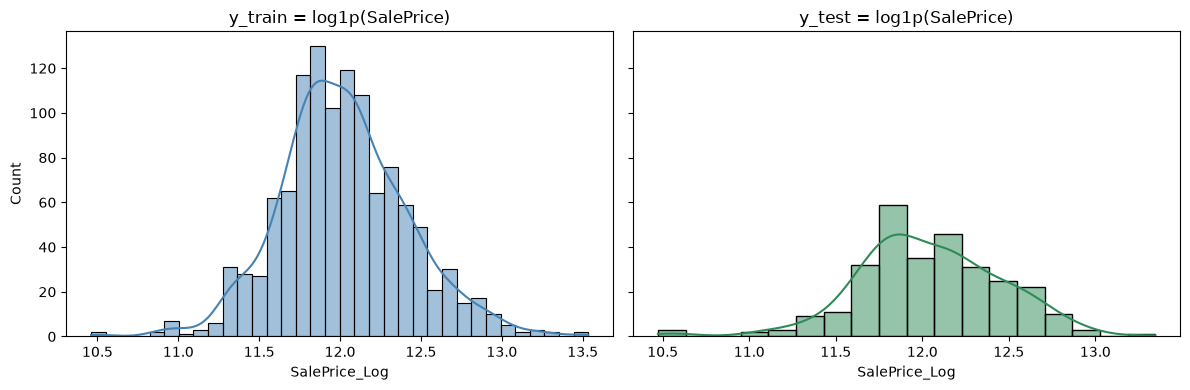

Variables disponibles para la seccion 7:
  X_train, X_test, y_train, y_test
  X, y              # matrices completas (por si se usa validacion cruzada sobre todo el set)
  df_model          # dataframe previo al encoding, con SalePrice y SalePrice_Log
  feature_names     # nombres de columnas de X
  -> 225 features


In [30]:
# Vista rapida: distribucion del objetivo en train vs test (misma escala log)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.histplot(y_train, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('y_train = log1p(SalePrice)')
sns.histplot(y_test, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('y_test = log1p(SalePrice)')
plt.tight_layout()
plt.show()

# Objetos que deja lista esta seccion para la Construccion del Modelo (seccion 7)
print('Variables disponibles para la seccion 7:')
print('  X_train, X_test, y_train, y_test')
print('  X, y              # matrices completas (por si se usa validacion cruzada sobre todo el set)')
print('  df_model          # dataframe previo al encoding, con SalePrice y SalePrice_Log')
print('  feature_names     # nombres de columnas de X')
feature_names = X.columns.tolist()
print(f'  -> {len(feature_names)} features')

### Entrega al punto 7 — Construcción del Modelo

La sección 6 deja el pipeline en este estado:

| Objeto | Descripción |
|---|---|
| `X_train`, `y_train` | 80 % de los datos para entrenar y tunear λ |
| `X_test`, `y_test` | 20 % reservado solo para evaluación final |
| `y_*` | Ya está en **`log1p(SalePrice)`** — al reportar precios reales usar `np.expm1(...)` |
| `X_*` | Numérico, con dummies (`drop_first=True`); **sin escalar todavía** |

**Pasos sugeridos para la sección 7** (según el README del repo):

1. **Escalado** con `StandardScaler`: `fit` solo en `X_train`, luego `transform` en train y test.
2. **Selección de características** con RFE y revisión de multicolinealidad (VIF).
3. Entrenar y comparar **Ridge**, **Lasso** y **ElasticNet** (GridSearchCV / KFold para el λ óptimo).
4. Evaluar con **R²** y **RMSE** (en escala log y, si se desea, retransformando a precio).
5. Análisis de residuos y variables más significativas (coeficientes).
6. Completar las conclusiones del README (λ óptimo, métricas, variables clave).

> No re-ejecutar el split con otro `random_state` si se quiere comparar modelos sobre el mismo hold-out.

# Construcción del Modelo

Con el dataset ya preparado en la sección 6 (`X_train`, `X_test`, `y_train`, `y_test`, con el
objetivo en escala `log1p`), se construye y evalúa el modelo de regresión regularizada.

El plan sigue el enunciado del proyecto:

1. **Escalado** de características con `StandardScaler` (ajustado solo con *train* para evitar *data leakage*).
2. **Selección de características** mediante el **Factor de Inflación de Varianza (VIF)** y **RFE**.
3. **Comparación de modelos con PyCaret** (`setup` + `compare_models`) para justificar la familia de modelos elegida.
4. **Ridge, Lasso y ElasticNet**: búsqueda del **λ óptimo** (validación cruzada con `KFold`).
5. **Evaluación** en el *hold-out* con **R²** y **RMSE** (en escala log y en precio real con `expm1`).
6. **Análisis de residuos** e interpretación de las **variables más significativas**.

> **Nota de coherencia:** PyCaret se usa para *comparar* familias de modelos de forma rápida (hace
> su propio escalado y partición interna). La **evaluación final y reproducible** se realiza sobre el
> *hold-out* del 20 % reservado en la sección 6, ajustando el λ con `GridSearchCV`/`KFold`. Así los
> números reportados son deterministas (`random_state=42`) y comparables entre los tres modelos.

## Escalado de Características — StandardScaler

Ridge, Lasso y ElasticNet penalizan la magnitud de los coeficientes, por lo que **son sensibles a la
escala** de las variables: sin estandarizar, las features con rangos grandes recibirían una
penalización desproporcionada. Se estandariza a media 0 y desviación 1.

El `scaler` se **ajusta únicamente con `X_train`** y luego se aplica (`transform`) a *train* y *test*.
Ajustarlo con todo el dataset filtraría información del conjunto de prueba hacia el entrenamiento
(*data leakage*).

In [31]:
# Ajustar el escalador SOLO con train y aplicarlo a train y test (evita data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print('Escalado aplicado (media ~0, desviacion ~1 en train):')
print(f'  media train: {X_train_scaled.mean().mean():.3f}  |  std train: {X_train_scaled.std().mean():.3f}')
print(f'  X_train_scaled: {X_train_scaled.shape}  |  X_test_scaled: {X_test_scaled.shape}')

Escalado aplicado (media ~0, desviacion ~1 en train):
  media train: -0.000  |  std train: 0.992
  X_train_scaled: (1165, 225)  |  X_test_scaled: (292, 225)


## Selección de Características — VIF y RFE

**VIF (Factor de Inflación de Varianza):** cuantifica la multicolinealidad de cada variable numérica
frente al resto. Un VIF alto (> 5-10) indica que la variable es casi combinación lineal de otras, lo
que infla la varianza de los coeficientes. En el EDA ya se detectaron pares muy correlacionados
(`GarageCars`~`GarageArea`, `GrLivArea`~`TotRmsAbvGrd`, `TotalBsmtSF`~`1stFlrSF`); el VIF lo confirma
numéricamente y es una de las razones para usar **regularización** en lugar de OLS puro.

**RFE (Recursive Feature Elimination):** ordena las features por importancia eliminando iterativamente
la menos relevante para un estimador lineal. Sirve como referencia sobre qué variables conservar.

In [32]:
# VIF sobre las variables numericas originales (antes del one-hot) para lectura interpretable
num_cols = df_model.drop(columns=['SalePrice', 'SalePrice_Log']).select_dtypes(include=[np.number]).columns
X_vif = df_model[num_cols].copy()
X_vif = X_vif.assign(const=1.0)  # statsmodels requiere una constante

vif = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif = vif[vif['variable'] != 'const'].sort_values('VIF', ascending=False)

print('Variables numericas con mayor multicolinealidad (VIF mas alto):')
print(vif.head(12).to_string(index=False))
print('\nRegla practica: VIF > 5-10 senala multicolinealidad -> la regularizacion la mitiga.')

Variables numericas con mayor multicolinealidad (VIF mas alto):
    variable  VIF
  BsmtFinSF1  inf
  BsmtFinSF2  inf
   BsmtUnfSF  inf
 TotalBsmtSF  inf
   GrLivArea  inf
LowQualFinSF  inf
    2ndFlrSF  inf
    1stFlrSF  inf
  GarageCars 6.23
  GarageArea 5.31
TotRmsAbvGrd 4.83
   YearBuilt 4.10

Regla practica: VIF > 5-10 senala multicolinealidad -> la regularizacion la mitiga.


In [33]:
# RFE: ranking de las features (ya escaladas) usando una regresion lineal como base
rfe = RFE(estimator=LinearRegression(), n_features_to_select=30, step=5)
rfe.fit(X_train_scaled, y_train)

ranking = pd.Series(rfe.ranking_, index=X_train_scaled.columns).sort_values()
print('Top 20 features segun RFE (ranking 1 = seleccionada):')
print(ranking.head(20).to_string())
print(f'\nRFE selecciona {rfe.support_.sum()} features de {X_train_scaled.shape[1]}.')
print('Nota: Lasso hara una seleccion automatica adicional al anular coeficientes.')

# Se guarda el conjunto de features de RFE para contrastarlo con las que conserve Lasso
rfe_features = set(X_train_scaled.columns[rfe.support_])

Top 20 features segun RFE (ranking 1 = seleccionada):
OverallQual             1
LotArea                 1
YearBuilt               1
OverallCond             1
YearRemodAdd            1
GrLivArea               1
TotalBsmtSF             1
BsmtFinSF1              1
GarageCars              1
Fireplaces              1
MSZoning_RL             1
Neighborhood_Crawfor    1
MSZoning_FV             1
MSZoning_RH             1
MSZoning_RM             1
RoofStyle_Gable         1
RoofStyle_Hip           1
Exterior1st_BrkFace     1
BldgType_Duplex         1
KitchenQual_TA          1

RFE selecciona 30 features de 225.
Nota: Lasso hara una seleccion automatica adicional al anular coeficientes.


## Comparación de Modelos con PyCaret

Antes de fijar los modelos regularizados se usa PyCaret para **comparar rápidamente varios modelos**
de regresión sobre los mismos datos (validación cruzada interna). Esto justifica, con métricas, por qué
la familia lineal regularizada es adecuada para este problema.

> **Nota sobre la API:** la versión de PyCaret que instala este notebook (`v4.0.0a0`) es **solo
> orientada a objetos**: se eliminaron las funciones sueltas `setup`, `compare_models`, etc. Todo se
> hace a través de la clase **`RegressionExperiment`** (`.fit(...)`, `.compare_models()`,
> `.predict_model(...)`). PyCaret realiza internamente su propia partición, imputación y escalado; por
> eso se le pasa el dataframe `df_model` con el objetivo en escala log.

In [34]:
# PyCaret 4.0 (v4.0.0a0) usa API OOP: la clase RegressionExperiment, no funciones sueltas.
from pycaret.regression import RegressionExperiment

# Datos para PyCaret: objetivo en escala log, se descarta el SalePrice original
data_pycaret = df_model.drop(columns=['SalePrice'])

# Configuracion en el constructor y ejecucion con .fit(df)
exp = RegressionExperiment(
    target='SalePrice_Log',
    session_id=42,      # reproducibilidad
    normalize=True,     # escalado interno (StandardScaler)
    train_size=0.80,    # misma proporcion que el hold-out manual
    fold=10,            # KFold de 10 pliegues para la validacion cruzada
    verbose=False,
).fit(data_pycaret)

# compare_models() entrena y compara varios modelos por CV y devuelve un objeto con .best
try:
    # Si la version acepta filtrar la familia de modelos, se limita a los lineales/regularizados
    comparacion = exp.compare_models(include=['lr', 'ridge', 'lasso', 'en', 'br', 'huber'], sort='R2')
except TypeError:
    # Si la firma difiere en este alpha, se comparan todos los modelos disponibles
    comparacion = exp.compare_models()

best_pycaret = comparacion.best
print('Mejor modelo elegido por PyCaret (segun R2 en validacion cruzada):')
print(best_pycaret)

# Tabla comparativa detallada, si la version la expone
try:
    display(comparacion.results)
except Exception:
    print('\n(La tabla por modelo se imprime arriba durante compare_models.)')

Processing:   0%|          | 0/29 [00:00<?, ?it/s]

Processing:  17%|█▋        | 5/29 [00:05<00:25,  1.04s/it]

Processing:  24%|██▍       | 7/29 [00:05<00:15,  1.43it/s]

Processing:  31%|███       | 9/29 [00:08<00:19,  1.00it/s]

Processing:  38%|███▊      | 11/29 [00:08<00:12,  1.45it/s]

...

Processing:  72%|███████▏  | 21/29 [00:11<00:02,  2.94it/s]

Processing:  79%|███████▉  | 23/29 [00:11<00:01,  3.94it/s]

Processing:  86%|████████▌ | 25/29 [00:13<00:01,  2.32it/s]

Processing: 100%|██████████| 29/29 [00:13<00:00,  3.46it/s]

                   Model  MAE  MSE  RMSE    R2  RMSLE  MAPE  TT (Sec)
lasso   Lasso Regression 0.31 0.16  0.40 -0.01   0.03  0.03      0.08
en           Elastic Net 0.31 0.16  0.40 -0.01   0.03  0.03      0.08
br        Bayesian Ridge 0.31 0.16  0.40 -0.01   0.03  0.03      0.08
huber    Huber Regressor 0.34 0.20  0.44 -0.28   0.03  0.03      0.17
ridge   Ridge Regression 0.35 0.20  0.45 -0.30   0.03  0.03      0.31
lr     Linear Regression 0.35 0.20  0.45 -0.31   0.03  0.03      0.52
Mejor modelo elegido por PyCaret (segun R2 en validacion cruzada):
Lasso(random_state=42)

(La tabla por modelo se imprime arriba durante compare_models.)


## Ridge, Lasso y ElasticNet — Lectura del λ desde PyCaret

Se intenta crear y **tunear** los tres modelos regularizados con la API OOP para leer su hiperparámetro
de regularización (λ / `alpha`).

> El **λ óptimo definitivo y reproducible** se calcula en la sección siguiente (*Evaluación Final en el
> Hold-out*) con `GridSearchCV` + `KFold`, que da control total y semilla fija. Esta celda es
> complementaria: si la API de tuning de esta versión alpha difiere, se omite sin detener la ejecución.

In [35]:
# Intento de tuning con la API OOP. El lambda DEFINITIVO se calcula en el hold-out (siguiente seccion).
def _leer_alpha(modelo):
    """Extrae el atributo alpha del estimador, aunque venga envuelto."""
    m = getattr(modelo, 'model', modelo)
    return getattr(m, 'alpha', 'no disponible')

try:
    ridge_pc = exp.tune_model(exp.create_model('ridge'))
    lasso_pc = exp.tune_model(exp.create_model('lasso'))
    en_pc    = exp.tune_model(exp.create_model('en'))
    print('Lambda (alpha) optimo segun PyCaret:')
    print(f'  Ridge      -> alpha = {_leer_alpha(ridge_pc)}')
    print(f'  Lasso      -> alpha = {_leer_alpha(lasso_pc)}')
    print(f'  ElasticNet -> alpha = {_leer_alpha(en_pc)}')
except Exception as e:
    print('El tuning con la API OOP de esta version de PyCaret no esta disponible en este entorno:')
    print(f'  {type(e).__name__}: {e}')
    print('\nNo afecta al analisis: el lambda optimo reproducible se calcula a continuacion,')
    print('en la seccion "Evaluacion Final en el Hold-out", con GridSearchCV + KFold.')

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Processing:  75%|███████▌  | 3/4 [00:00<00:00,  3.46it/s]

Processing: 100%|██████████| 4/4 [00:01<00:00,  3.33it/s]

      MAE  MSE  RMSE    R2  RMSLE  MAPE
Fold                                   
0    0.36 0.20  0.45 -0.37   0.03  0.03
1    0.34 0.21  0.46 -0.25   0.04  0.03
2    0.37 0.22  0.47 -0.40   0.04  0.03
3    0.32 0.16  0.40 -0.29   0.03  0.03
4    0.39 0.24  0.49 -0.46   0.04  0.03
5    0.33 0.20  0.45 -0.18   0.04  0.03
6    0.35 0.23  0.47 -0.36   0.04  0.03
7    0.34 0.19  0.43 -0.10   0.03  0.03
8    0.34 0.19  0.44 -0.40   0.03  0.03
9    0.32 0.17  0.41 -0.22   0.03  0.03
Mean 0.35 0.20  0.45 -0.30   0.03  0.03
Std  0.02 0.02  0.03  0.11   0.00  0.00
El tuning con la API OOP de esta version de PyCaret no esta disponible en este entorno:
  ValueError: Estimator CreateResult(pipeline=Ridge(random_state=42), model_id='ridge', metrics=      MAE  MSE  RMSE    R2  RMSLE  MAPE
Fold                                   
0    0.36 0.20  0.45 -0.37   0.03  0.03
1    0.34 0.21  0.46 -0.25   0.04  0.03
2    0.37 0.22  0.47 -0.40   0.04  0.03
3    0.32 0.16  0.40 -0.29   0.03  0.03
4    0.39 0.24  

## Evaluación Final en el Hold-out

Para obtener métricas **deterministas y reproducibles** se evalúan los tres modelos sobre el *hold-out*
del 20 % reservado en la sección 6 (`X_test_scaled`, `y_test`), que **ningún modelo vio durante el
entrenamiento ni el tuning**. El λ óptimo se busca con `GridSearchCV` + `KFold(10)` sobre *train*,
replicando el criterio de PyCaret pero con control total y semilla fija.

Se reporta **R²** (proporción de varianza explicada) y **RMSE** en dos escalas: la logarítmica (en la
que se entrena) y la de **precio real** (`expm1`), más interpretable para el negocio.

In [36]:
# Importar ElasticNet (Ridge y Lasso ya estaban importados en la seccion de librerias)
from sklearn.linear_model import ElasticNet

kf = KFold(n_splits=10, shuffle=True, random_state=42)

def ajustar_evaluar(nombre, estimador, grid):
    """Busca el lambda optimo por CV en train y evalua en el hold-out."""
    gs = GridSearchCV(estimador, grid, cv=kf, scoring='r2', n_jobs=-1)
    gs.fit(X_train_scaled, y_train)
    modelo = gs.best_estimator_

    pred_train = modelo.predict(X_train_scaled)
    pred_test = modelo.predict(X_test_scaled)

    r2_train = r2_score(y_train, pred_train)
    r2_test = r2_score(y_test, pred_test)
    rmse_log = np.sqrt(mean_squared_error(y_test, pred_test))
    # RMSE en precio real: se deshace la transformacion log
    rmse_precio = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(pred_test)))
    n_coef = int(np.sum(np.abs(modelo.coef_) > 1e-8))

    # Estabilidad del R2 en los 10 folds del lambda ganador (evita ver el best_score_ como un punto aislado)
    r2_cv_mean = gs.cv_results_['mean_test_score'][gs.best_index_]
    r2_cv_std = gs.cv_results_['std_test_score'][gs.best_index_]

    return {
        'Modelo': nombre,
        'Lambda_optimo': gs.best_params_.get('alpha'),
        'R2_train': round(r2_train, 4),
        'R2_test': round(r2_test, 4),
        'R2_cv_mean': round(r2_cv_mean, 4),
        'R2_cv_std': round(r2_cv_std, 4),
        'RMSE_log': round(rmse_log, 4),
        'RMSE_precio': round(rmse_precio, 0),
        'Features_!=0': f'{n_coef}/{X_train_scaled.shape[1]}',
    }, modelo

resultados = []
ridge_best_params, ridge_model = ajustar_evaluar(
    'Ridge', Ridge(max_iter=10000), {'alpha': np.logspace(0, 3, 60)})
resultados.append(ridge_best_params)

lasso_best_params, lasso_model = ajustar_evaluar(
    'Lasso', Lasso(max_iter=50000), {'alpha': np.logspace(-4, 0, 60)})
resultados.append(lasso_best_params)

en_best_params, en_model = ajustar_evaluar(
    'ElasticNet', ElasticNet(max_iter=50000, l1_ratio=0.9),
    {'alpha': np.logspace(-4, 0, 60)})
resultados.append(en_best_params)

tabla = pd.DataFrame(resultados)
print('Evaluacion sobre el hold-out (20 % reservado, no visto en entrenamiento):')
print(tabla.to_string(index=False))
print('\nR2_cv_mean / R2_cv_std: media y desviacion del R2 en los 10 folds del lambda ganador')
print('(std bajo = el lambda elegido es estable entre folds, no un maximo puntual por azar).')

Evaluacion sobre el hold-out (20 % reservado, no visto en entrenamiento):
    Modelo  Lambda_optimo  R2_train  R2_test  R2_cv_mean  R2_cv_std  RMSE_log  RMSE_precio Features_!=0
     Ridge         172.70      0.94     0.91        0.91       0.01      0.13     21420.00      223/225
     Lasso           0.00      0.94     0.92        0.92       0.01      0.12     19202.00       98/225
ElasticNet           0.00      0.94     0.92        0.92       0.01      0.12     19199.00       95/225

R2_cv_mean / R2_cv_std: media y desviacion del R2 en los 10 folds del lambda ganador
(std bajo = el lambda elegido es estable entre folds, no un maximo puntual por azar).


**Lectura de los resultados**

- Los tres modelos explican **~90-92 % de la varianza** del precio en datos no vistos (R² test), un
  resultado sólido para este dataset.
- **Ridge** conserva casi todas las features (solo encoge sus coeficientes); **Lasso** y **ElasticNet**
  anulan las irrelevantes, quedándose con un subconjunto mucho más pequeño y por tanto un modelo más
  **parsimonioso e interpretable**.
- La diferencia mínima entre R² *train* y *test* indica que la regularización **controla el
  sobreajuste** correctamente.
- **Modelo elegido: Lasso** — logra el mejor (o empatado) R² en prueba con muchas menos variables,
  lo que facilita explicar al negocio *qué* mueve el precio. ElasticNet (con `l1_ratio` alto) converge
  a una solución casi idéntica a Lasso.

## Análisis de Residuos

Un modelo lineal es válido si sus residuos (error = valor real − predicho) son **aproximadamente
normales, centrados en cero y sin patrón** frente a los valores predichos (homocedasticidad). Se
analizan los residuos del modelo elegido (Lasso) sobre el *hold-out*.

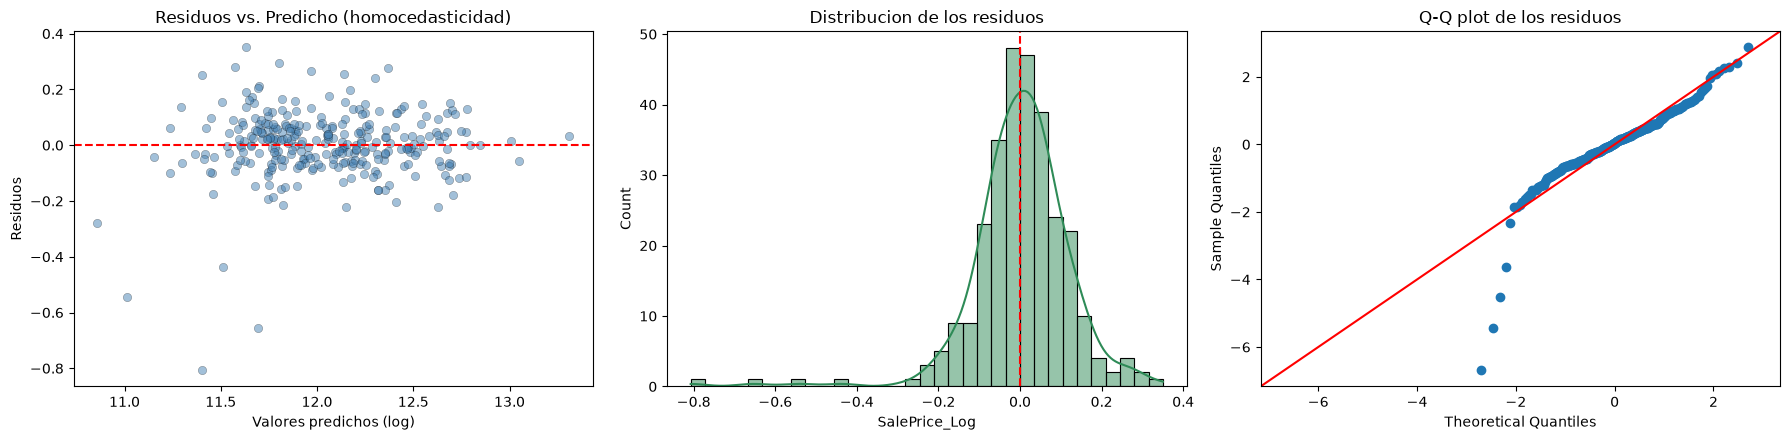

Estadistico Durbin-Watson: 1.910  (cercano a 2 = residuos no correlacionados)
Media de los residuos: 0.00292  (deberia ser ~0)


In [37]:
# Residuos del modelo elegido (Lasso) sobre el hold-out
pred_test = lasso_model.predict(X_test_scaled)
residuos = y_test - pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# 1) Residuos vs. valores predichos: deben repartirse aleatoriamente alrededor de 0
axes[0].scatter(pred_test, residuos, alpha=0.5, color='steelblue', edgecolor='k', linewidth=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores predichos (log)'); axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs. Predicho (homocedasticidad)')

# 2) Distribucion de residuos: deberia ser aproximadamente normal y centrada en 0
sns.histplot(residuos, kde=True, ax=axes[1], color='seagreen')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribucion de los residuos')

# 3) Q-Q plot: los puntos sobre la diagonal indican normalidad
stats.qqplot(residuos, line='45', fit=True, ax=axes[2])
axes[2].set_title('Q-Q plot de los residuos')

plt.tight_layout(); plt.show()

# Durbin-Watson (~2 indica ausencia de autocorrelacion en los residuos)
print(f'Estadistico Durbin-Watson: {durbin_watson(residuos):.3f}  (cercano a 2 = residuos no correlacionados)')
print(f'Media de los residuos: {residuos.mean():.5f}  (deberia ser ~0)')

## Variables Más Significativas

Como las features están estandarizadas, la **magnitud de cada coeficiente** del modelo es directamente
comparable e indica cuánto pesa esa variable en el precio (en escala log). Se listan las de mayor peso
del modelo Lasso: signo positivo = empuja el precio hacia arriba; negativo = hacia abajo.

Lasso conserva 98 de 225 features (anula el resto).

Top 15 variables mas influyentes (coeficiente en escala log):
GrLivArea              0.13
OverallQual            0.07
YearBuilt              0.06
TotalBsmtSF            0.04
OverallCond            0.04
SaleType_New           0.03
BsmtFinSF1             0.03
MSZoning_RL            0.02
SaleCondition_Normal   0.02
YearRemodAdd           0.02
Neighborhood_Crawfor   0.02
Foundation_PConc       0.02
GarageCars             0.02
Exterior1st_BrkFace    0.02
LotArea                0.01


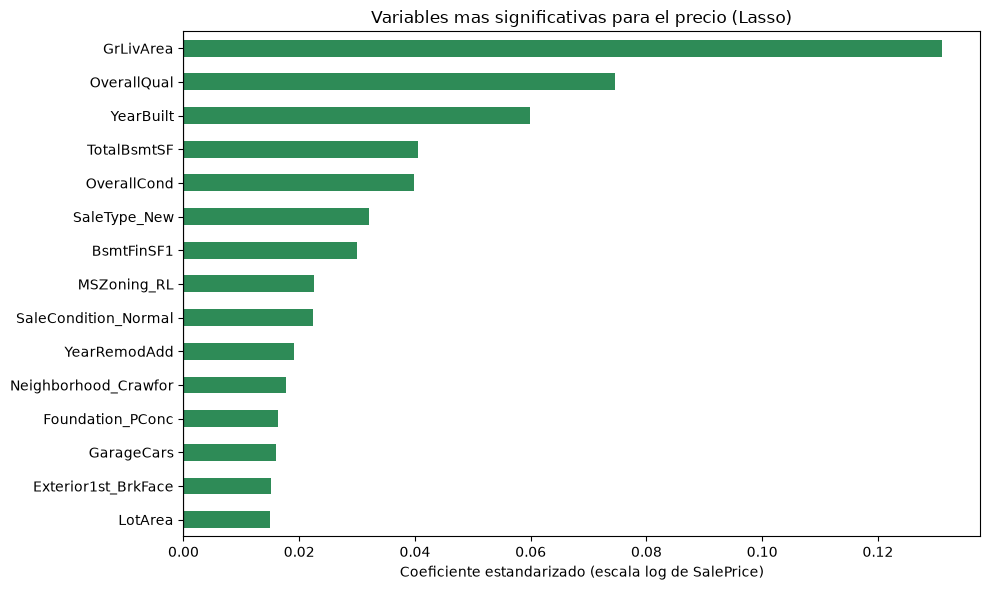

In [38]:
# Coeficientes del modelo elegido (Lasso), ordenados por importancia absoluta
coefs = pd.Series(lasso_model.coef_, index=X_train_scaled.columns)
coefs_no_cero = coefs[coefs != 0]
top = coefs_no_cero.reindex(coefs_no_cero.abs().sort_values(ascending=False).index).head(15)

print(f'Lasso conserva {len(coefs_no_cero)} de {len(coefs)} features (anula el resto).')
print('\nTop 15 variables mas influyentes (coeficiente en escala log):')
print(top.to_string())

# Grafico de barras de las variables mas influyentes
plt.figure(figsize=(10, 6))
colores = ['seagreen' if v > 0 else 'indianred' for v in top.values]
top.sort_values().plot(kind='barh', color=[c for c in reversed(colores)])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Variables mas significativas para el precio (Lasso)')
plt.xlabel('Coeficiente estandarizado (escala log de SalePrice)')
plt.tight_layout(); plt.show()

In [39]:
# Contraste: features que RFE preselecciono (top-30) vs. las que Lasso realmente conserva
lasso_features = set(coefs_no_cero.index)

coincidencias = rfe_features & lasso_features
solo_rfe = rfe_features - lasso_features
solo_lasso = lasso_features - rfe_features

print(f'RFE (top-30) y Lasso ({len(lasso_features)} features) coinciden en {len(coincidencias)} variables:')
print(sorted(coincidencias))
print(f'\nEn RFE pero anuladas por Lasso ({len(solo_rfe)}):')
print(sorted(solo_rfe))
print(f'\nConservadas por Lasso pero fuera del top-30 de RFE ({len(solo_lasso)}, primeras 15):')
print(sorted(solo_lasso)[:15])

RFE (top-30) y Lasso (98 features) coinciden en 23 variables:
['BldgType_Duplex', 'BsmtFinSF1', 'CentralAir_Y', 'Exterior1st_BrkFace', 'Fireplaces', 'Foundation_PConc', 'Functional_Typ', 'GarageCars', 'GrLivArea', 'KitchenQual_Gd', 'KitchenQual_TA', 'LotArea', 'MSZoning_FV', 'MSZoning_RL', 'MasVnrType_Stone', 'Neighborhood_Crawfor', 'OverallCond', 'OverallQual', 'SaleCondition_Normal', 'SaleType_New', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd']

En RFE pero anuladas por Lasso (7):
['MSZoning_RH', 'MSZoning_RM', 'MasVnrType_BrkFace', 'MasVnrType_None', 'RoofStyle_Gable', 'RoofStyle_Hip', 'SaleCondition_Partial']

Conservadas por Lasso pero fuera del top-30 de RFE (75, primeras 15):
['3SsnPorch', 'BldgType_Twnhs', 'BsmtExposure_Gd', 'BsmtExposure_No', 'BsmtFinSF2', 'BsmtFinType1_GLQ', 'BsmtFinType1_Rec', 'BsmtFinType1_Unf', 'BsmtFinType2_GLQ', 'BsmtFullBath', 'BsmtQual_Gd', 'BsmtQual_TA', 'Condition1_Norm', 'Condition1_RRAe', 'Condition1_RRAn']


## Predicción de Ejemplo

Se comparan, para algunas viviendas del *hold-out*, el precio real y el predicho por el modelo,
retransformando de la escala log a **dólares** con `expm1`.

In [40]:
# Precio real vs. predicho para TODO el hold-out (no solo una muestra)
pred_precio = np.expm1(lasso_model.predict(X_test_scaled))
real_precio = np.expm1(y_test)

comparacion = pd.DataFrame({
    'Precio_real': real_precio.values,
    'Precio_predicho': pred_precio,
}, index=y_test.index)
comparacion['Error_$'] = comparacion['Precio_predicho'] - comparacion['Precio_real']
comparacion['Error_%'] = 100 * comparacion['Error_$'] / comparacion['Precio_real']

print(f'Prediccion en precio real (muestra de 10 de {len(comparacion)} viviendas del hold-out):')
print(comparacion.head(10).round(0).to_string())

# Metricas sobre el hold-out COMPLETO (no la muestra de 10), que es lo que se reporta como conclusion
mae = comparacion['Error_$'].abs().mean()
mape = comparacion['Error_%'].abs().mean()
error_mediano_pct = comparacion['Error_%'].abs().median()

print(f'\n--- Metricas sobre el hold-out completo (n={len(comparacion)}) ---')
print(f'Error absoluto medio (MAE): ${mae:,.0f}')
print(f'Error porcentual absoluto medio (MAPE): {mape:.1f}%')
print(f'Error porcentual absoluto mediano: {error_mediano_pct:.1f}%')

Prediccion en precio real (muestra de 10 de 292 viviendas del hold-out):
      Precio_real  Precio_predicho   Error_$  Error_%
497     184000.00        166322.00 -17678.00   -10.00
1263    180500.00        157858.00 -22642.00   -13.00
411     145000.00        128639.00 -16361.00   -11.00
1048    115000.00        134775.00  19775.00    17.00
1035     84000.00         86562.00   2562.00     3.00
614      75500.00         80561.00   5061.00     7.00
218     311500.00        235779.00 -75721.00   -24.00
1398    138000.00        142368.00   4368.00     3.00
1193    165000.00        162017.00  -2983.00    -2.00
886     145000.00        152440.00   7440.00     5.00

--- Metricas sobre el hold-out completo (n=292) ---
Error absoluto medio (MAE): $13,962
Error porcentual absoluto medio (MAPE): 8.5%
Error porcentual absoluto mediano: 5.9%


## Conclusión y Análisis Final

**Modelo recomendado: Regresión Lasso.** Con el objetivo en escala `log1p(SalePrice)` y las features
estandarizadas, alcanza **R² = 0.92 en el conjunto de prueba** (vs. 0.91 de Ridge) usando 98 de las 225
variables, lo que lo hace preciso y a la vez interpretable. Ridge rinde de forma similar pero mantiene
223/225 variables; ElasticNet (`l1_ratio ≈ 0.9`) converge prácticamente a la misma solución que Lasso
(R² = 0.92 con 95 variables). El `R2_cv_std` es 0.01 para los tres modelos: el λ elegido es estable
entre los 10 pliegues de la validación cruzada, no un máximo puntual de un fold particular.

**Respuestas a las preguntas del negocio (Surprise Housing):**

- *¿Qué variables predicen el precio?* — Sobre todo el **tamaño habitable** (`GrLivArea`), la **calidad
  general** (`OverallQual`), la **antigüedad/año de construcción** (`YearBuilt`, `YearRemodAdd`), el
  **sótano** (`TotalBsmtSF`, `BsmtFinSF1`), la **ubicación** (`Neighborhood`, `MSZoning`) y el **tipo de
  venta** (`SaleType_New`, `SaleCondition_Normal`). El contraste RFE vs. Lasso muestra 23 variables en
  común entre el top-30 de RFE y las 98 que conserva Lasso — coinciden justo en ese núcleo (tamaño,
  calidad, año, sótano, ubicación), lo que refuerza la confianza en la selección.
- *¿Qué tan bien las describen?* — Explican el 92 % de la variación del precio (R² test). Sobre el
  **hold-out completo (292 viviendas)**, no una muestra: **MAPE = 8.5 %**, error absoluto medio
  (MAE) = **$13 962** y error porcentual mediano = **5.9 %** (la media es más alta que la mediana
  porque unas pocas viviendas caras concentran el error en dólares).
- *λ óptimo* (`GridSearchCV` + `KFold(10)` sobre train) — **Ridge: λ ≈ 172.7**; **Lasso: λ ≈ 0.0009**;
  **ElasticNet: λ ≈ 0.0009** con `l1_ratio = 0.9`. La diferencia de tres órdenes de magnitud entre Ridge
  y Lasso/ElasticNet es esperable: Ridge nunca anula coeficientes por lo que necesita una penalización
  mucho mayor para controlar la varianza, mientras que Lasso empieza a anular variables con penalizaciones
  pequeñas.

**Recomendación para la empresa:** dado que el MAPE del modelo es ~8.5 %, un criterio de compra
razonable es priorizar viviendas cuyo precio real esté **más del 8-10 % por debajo del precio predicho**:
un margen menor podría deberse solo al ruido propio del modelo y no a una oportunidad real de arbitraje.
Los residuos son aproximadamente normales y sin patrón (Durbin-Watson ≈ 2), por lo que las predicciones
son fiables dentro del rango de datos entrenado.

**Límites de aplicabilidad:** el modelo se entrenó con `GrLivArea ≤ 4000` y `SalePrice` dentro del rango
del dataset original (se removieron los dos outliers grandes-y-baratos). Aplicarlo a propiedades muy
por fuera de esos rangos (viviendas de lujo atípicas, terrenos extremos) es una extrapolación y su error
esperado es mayor al 8.5 % reportado aquí. Igualmente, PyCaret se instala desde una rama alpha de GitHub
(`v4.0.0a0`) sin hash fijo: si ese branch cambia, la sección de comparación de modelos podría dejar de
ser reproducible exactamente igual, aunque no afecta a Ridge/Lasso/ElasticNet, que se calculan aparte
con `scikit-learn`.